
=== 0.4 kV-nivå (illustrativt) ===
U_LL,s = 400.0 V
I = 200.0 A
cos(phi) = 0.950
phi = 18.195 deg
R20 = 0.030000 ohm
X = 0.008000 ohm

Vid 10 °C:
  R(10)      = 0.028791 ohm
  Vr_LL(10)  = 389.66 V
  Vr_ang(10) = 0.070801 deg
  P_loss(10) = 3454.92 W

Vid 90 °C:
  R(90)      = 0.038463 ohm
  Vr_LL(90)  = 386.48 V
  Vr_ang(90) = 0.226482 deg
  P_loss(90) = 4615.56 W

Skillnad 10 -> 90 °C:
  Delta R      = 0.009672 ohm
  Delta Vr_LL  = -3.18 V
  Delta Vr_ang = 0.155681 deg
  Delta P_loss = 1160.64 W

=== 11 kV-nivå (illustrativt) ===
U_LL,s = 11000.0 V
I = 200.0 A
cos(phi) = 0.950
phi = 18.195 deg
R20 = 0.800000 ohm
X = 0.450000 ohm

Vid 10 °C:
  R(10)      = 0.767760 ohm
  Vr_LL(10)  = 10698.86 V
  Vr_ang(10) = -0.348335 deg
  P_loss(10) = 92131.20 W

Vid 90 °C:
  R(90)      = 1.025680 ohm
  Vr_LL(90)  = 10613.85 V
  Vr_ang(90) = -0.200523 deg
  P_loss(90) = 123081.60 W

Skillnad 10 -> 90 °C:
  Delta R      = 0.257920 ohm
  Delta Vr_LL  = -85.01 V
  Delta Vr_ang = 0.147813 deg
  Delta 

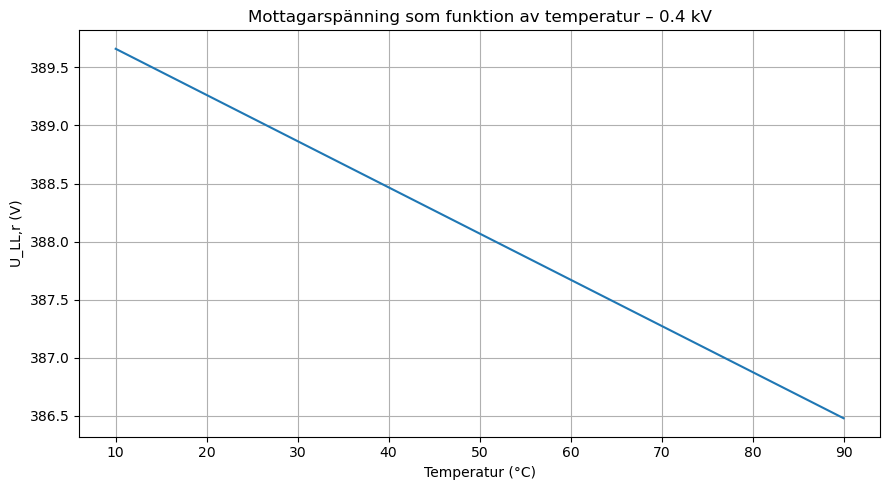

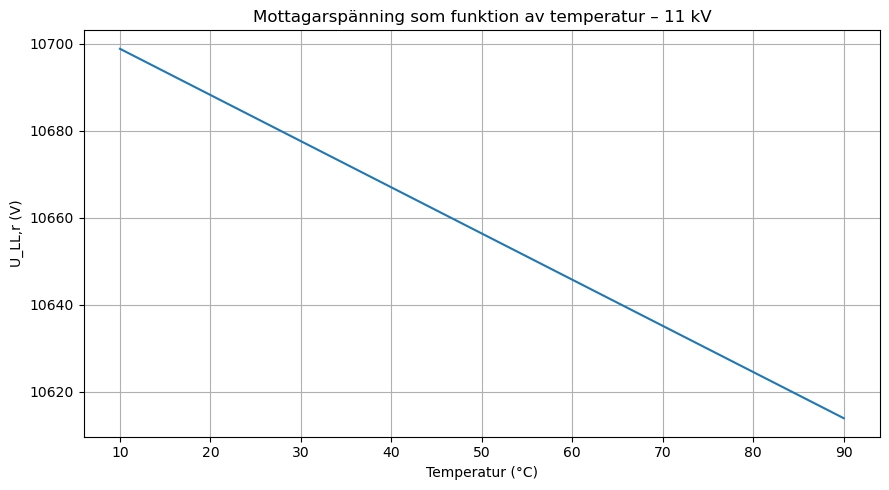

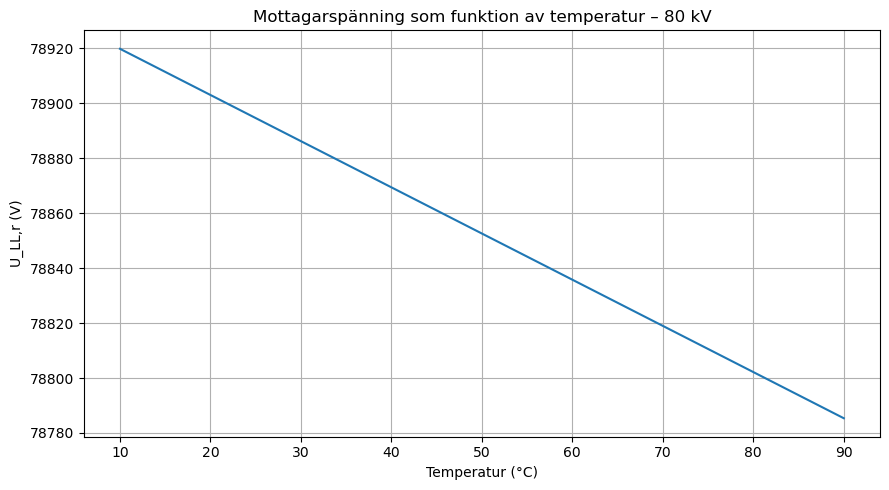

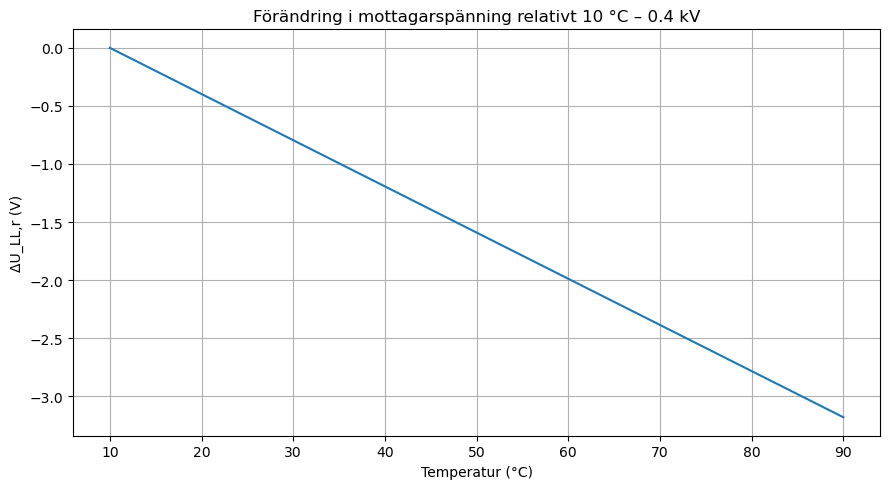

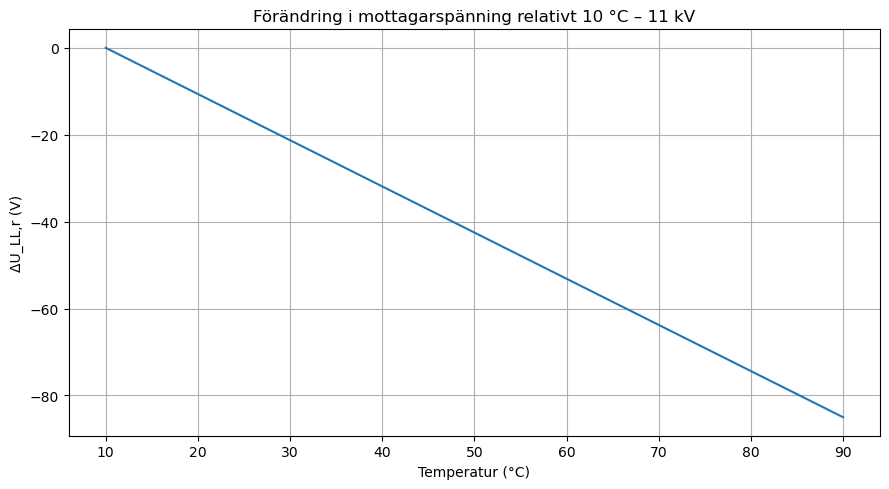

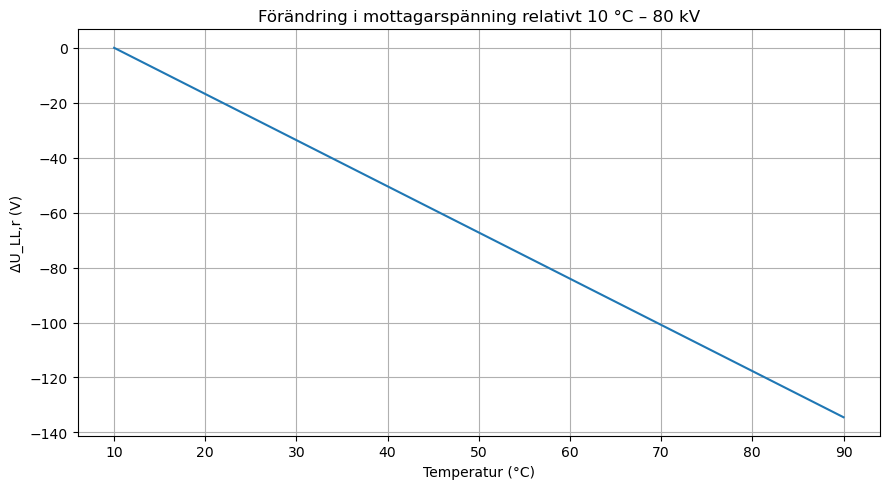

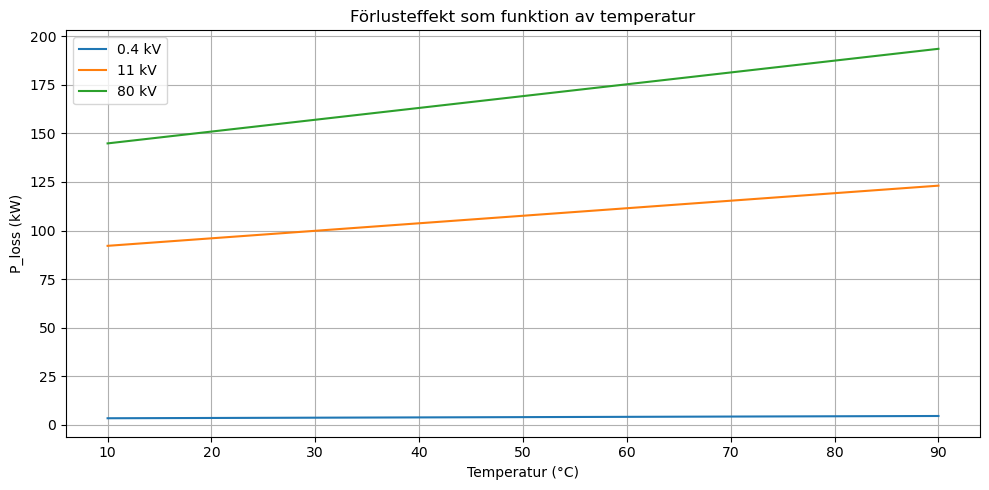

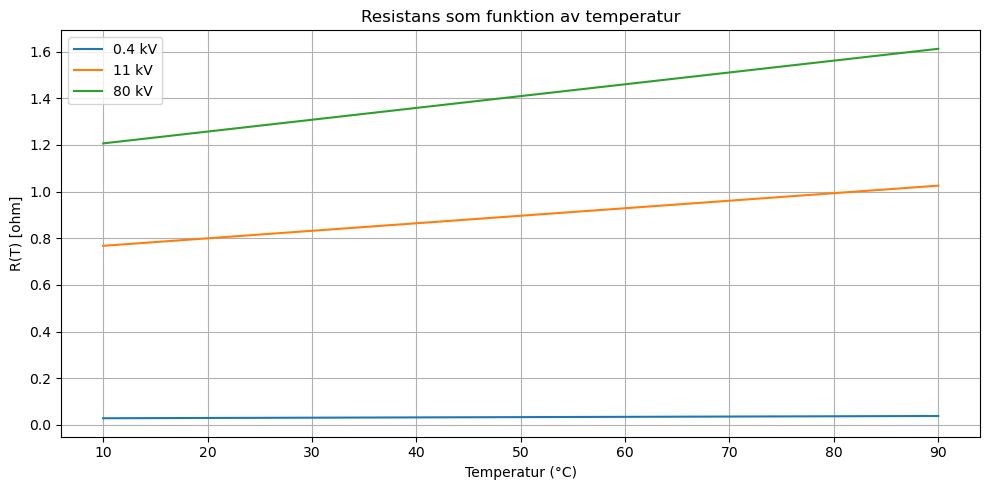


=== SAMMANFATTNING MED EXTRA KOLUMNER ===
  Exempel  R_10_Ohm  R_90_Ohm  Delta_R_per_5C_Ohm     Vr_10_V     Vr_90_V  \
0  0.4 kV    0.0288    0.0385              0.0006    389.6601    386.4799   
1   11 kV    0.7678    1.0257              0.0161  10698.8609  10613.8494   
2   80 kV    1.2068    1.6122              0.0253  78919.8417  78785.3510   

   Delta_Vr_V  Delta_Vr_pct  Delta_Vr_per_5C_V  P_loss_10_W  P_loss_90_W  \
0     -3.1802       -0.8162            -0.1988      3454.92      4615.56   
1    -85.0115       -0.7946            -5.3132     92131.20    123081.60   
2   -134.4906       -0.1704            -8.4057    144818.73    193468.89   

   Delta_P_loss_W  Delta_P_loss_per_5C_W  Delta_P_loss_per_5C_kW  
0         1160.64                 72.540                  0.0725  
1        30950.40               1934.400                  1.9344  
2        48650.16               3040.635                  3.0406  


In [3]:
# ============================================================
# FRAMÅTRIKTAD LÄNKMODELL:
# Hur mycket ändras andra sidan när temperaturen går 10 -> 90 °C?
#
# Idé:
#   1. Välj ett driftfall på sändarsidan:
#        U_LL,s, I och cos(phi)
#   2. Håll U_s, I och cos(phi) konstanta
#   3. Låt bara R(T) ändras med temperaturen
#   4. Beräkna V_r(T), P_r(T) och P_loss(T)
#
# Detta är en enkel seriemodell per fas:
#       V_s = V_r + Z(T) I
#       V_r = V_s - Z(T) I
#       Z(T) = R(T) + jX
#       R(T) = R20 * (1 + alpha * (T - 20))
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alpha = 0.00403  # 1/K

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def run_case(label, U_LL_s, I_A, cosphi, R20_ohm, X_ohm, T_min=10, T_max=90):
    # Effektfaktorvinkel
    phi_deg = np.degrees(np.arccos(cosphi))

    # Per-fas modell (balanserad trefas)
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)      # sändarspänning som referens
    Iph = polar(I_A, -phi_deg)                # induktiv last: ström efter spänning

    rows = []
    for T in range(T_min, T_max + 1):
        R = R20_ohm * (1 + alpha * (T - 20.0))
        Z = R + 1j * X_ohm

        Vr = Vs - Z * Iph
        Sr = 3 * Vr * np.conj(Iph)            # total trefaseffekt i mottagaränden
        Pr = np.real(Sr)
        Qr = np.imag(Sr)

        P_loss = 3 * (I_A ** 2) * R           # total trefas I²R-förlust

        rows.append({
            "T_C": T,
            "R_Ohm": R,
            "X_Ohm": X_ohm,
            "Vr_LL_V": abs(Vr) * np.sqrt(3),
            "Vr_ang_deg": np.degrees(np.angle(Vr)),
            "P_rec_W": Pr,
            "Q_rec_var": Qr,
            "P_loss_W": P_loss,
        })

    df = pd.DataFrame(rows)

    print(f"\n=== {label} ===")
    print(f"U_LL,s = {U_LL_s:.1f} V")
    print(f"I = {I_A:.1f} A")
    print(f"cos(phi) = {cosphi:.3f}")
    print(f"phi = {phi_deg:.3f} deg")
    print(f"R20 = {R20_ohm:.6f} ohm")
    print(f"X = {X_ohm:.6f} ohm")

    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    print("\nVid 10 °C:")
    print(f"  R(10)      = {row10['R_Ohm']:.6f} ohm")
    print(f"  Vr_LL(10)  = {row10['Vr_LL_V']:.2f} V")
    print(f"  Vr_ang(10) = {row10['Vr_ang_deg']:.6f} deg")
    print(f"  P_loss(10) = {row10['P_loss_W']:.2f} W")

    print("\nVid 90 °C:")
    print(f"  R(90)      = {row90['R_Ohm']:.6f} ohm")
    print(f"  Vr_LL(90)  = {row90['Vr_LL_V']:.2f} V")
    print(f"  Vr_ang(90) = {row90['Vr_ang_deg']:.6f} deg")
    print(f"  P_loss(90) = {row90['P_loss_W']:.2f} W")

    print("\nSkillnad 10 -> 90 °C:")
    print(f"  Delta R      = {row90['R_Ohm'] - row10['R_Ohm']:.6f} ohm")
    print(f"  Delta Vr_LL  = {row90['Vr_LL_V'] - row10['Vr_LL_V']:.2f} V")
    print(f"  Delta Vr_ang = {row90['Vr_ang_deg'] - row10['Vr_ang_deg']:.6f} deg")
    print(f"  Delta P_loss = {row90['P_loss_W'] - row10['P_loss_W']:.2f} W")

    return df

# ============================================================
# TRE EXEMPEL
# 0.4 kV och 11 kV är illustrativa
# 80 kV använder Bohus-lik nivå:
#   R20 = 0.0729*17.25 = 1.2575 ohm
#   X   = 0.38*17.25   = 6.555 ohm
# ============================================================

df_04 = run_case(
    label="0.4 kV-nivå (illustrativt)",
    U_LL_s=400.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=0.030,
    X_ohm=0.008
)

df_11 = run_case(
    label="11 kV-nivå (illustrativt)",
    U_LL_s=11000.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=0.800,
    X_ohm=0.450
)

df_80 = run_case(
    label="80 kV-nivå (Bohus-lik)",
    U_LL_s=80000.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=1.2575,
    X_ohm=6.555
)

# ============================================================
# TABELL MED 10 °C och 90 °C
# ============================================================

def pick_summary(df, label):
    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]
    return {
        "Exempel": label,
        "R_10_Ohm": row10["R_Ohm"],
        "R_90_Ohm": row90["R_Ohm"],
        "Vr_10_V": row10["Vr_LL_V"],
        "Vr_90_V": row90["Vr_LL_V"],
        "Delta_Vr_V": row90["Vr_LL_V"] - row10["Vr_LL_V"],
        "P_loss_10_W": row10["P_loss_W"],
        "P_loss_90_W": row90["P_loss_W"],
        "Delta_P_loss_W": row90["P_loss_W"] - row10["P_loss_W"],
    }

summary = pd.DataFrame([
    pick_summary(df_04, "0.4 kV"),
    pick_summary(df_11, "11 kV"),
    pick_summary(df_80, "80 kV"),
])

print("\n=== SAMMANFATTNING ===")
print(summary)

# ============================================================
# PLOT 1: Mottagarspänning vs temperatur
# SEPARATA GRAFER
# ============================================================

cases = [
    ("0.4 kV", df_04),
    ("11 kV", df_11),
    ("80 kV", df_80),
]

for label, df_case in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["Vr_LL_V"])
    plt.title(f"Mottagarspänning som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# ============================================================
# PLOT 1B: Spänningsändring relativt 10 °C
# ============================================================

cases = [
    ("0.4 kV", df_04),
    ("11 kV", df_11),
    ("80 kV", df_80),
]

for label, df_case in cases:
    Vr0 = df_case.loc[df_case["T_C"] == 10, "Vr_LL_V"].iloc[0]
    delta_V = df_case["Vr_LL_V"] - Vr0

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], delta_V)
    plt.title(f"Förändring i mottagarspänning relativt 10 °C – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("ΔU_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# ============================================================
# PLOT 2: Förlusteffekt vs temperatur
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["P_loss_W"]/1000, label="0.4 kV")
plt.plot(df_11["T_C"], df_11["P_loss_W"]/1000, label="11 kV")
plt.plot(df_80["T_C"], df_80["P_loss_W"]/1000, label="80 kV")
plt.title("Förlusteffekt som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("P_loss (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: Resistans vs temperatur
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["R_Ohm"], label="0.4 kV")
plt.plot(df_11["T_C"], df_11["R_Ohm"], label="11 kV")
plt.plot(df_80["T_C"], df_80["R_Ohm"], label="80 kV")
plt.title("Resistans som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("R(T) [ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# EXTRA KOLUMNER I SAMMANFATTNINGSTABELLEN
# ============================================================

# temperaturintervallet i exemplet är 10 -> 90 °C
delta_T_total = 90 - 10
n_5C_steps = delta_T_total / 5.0   # = 16 steg om 5 °C

# 1. relativ spänningsändring i %
# signed: negativt värde betyder att mottagarspänningen minskar
summary["Delta_Vr_pct"] = 100.0 * summary["Delta_Vr_V"] / summary["Vr_10_V"]

# 2. spänningsändring per 5 °C
summary["Delta_Vr_per_5C_V"] = summary["Delta_Vr_V"] / n_5C_steps

# 3. förluständring per 5 °C
summary["Delta_P_loss_per_5C_W"] = summary["Delta_P_loss_W"] / n_5C_steps
summary["Delta_P_loss_per_5C_kW"] = summary["Delta_P_loss_per_5C_W"] / 1000.0

# valfritt men bra: även resistansändring per 5 °C
summary["Delta_R_per_5C_Ohm"] = (summary["R_90_Ohm"] - summary["R_10_Ohm"]) / n_5C_steps

# snyggare visning
summary_view = summary[[
    "Exempel",
    "R_10_Ohm", "R_90_Ohm", "Delta_R_per_5C_Ohm",
    "Vr_10_V", "Vr_90_V", "Delta_Vr_V", "Delta_Vr_pct", "Delta_Vr_per_5C_V",
    "P_loss_10_W", "P_loss_90_W", "Delta_P_loss_W", "Delta_P_loss_per_5C_W", "Delta_P_loss_per_5C_kW"
]].copy()

print("\n=== SAMMANFATTNING MED EXTRA KOLUMNER ===")
print(summary_view.round(4))


=== 0.4 kV ===
U_LL,s = 400.0 V
I = 200.0 A
cos(phi) = 0.950
phi = 18.195 deg
R20 = 0.030000 ohm
X = 0.008000 ohm

Vid 10 °C:
  R(10)      = 0.028791 ohm
  Vr_LL(10)  = 389.66 V
  Vr_ang(10) = 0.070801 deg
  P_loss(10) = 3454.92 W

Vid 90 °C:
  R(90)      = 0.038463 ohm
  Vr_LL(90)  = 386.48 V
  Vr_ang(90) = 0.226482 deg
  P_loss(90) = 4615.56 W

Skillnad 10 -> 90 °C:
  Delta R      = 0.009672 ohm
  Delta Vr_LL  = -3.18 V
  Delta Vr_ang = 0.155681 deg
  Delta P_loss = 1160.64 W

=== 11 kV ===
U_LL,s = 11000.0 V
I = 200.0 A
cos(phi) = 0.950
phi = 18.195 deg
R20 = 0.800000 ohm
X = 0.450000 ohm

Vid 10 °C:
  R(10)      = 0.767760 ohm
  Vr_LL(10)  = 10698.86 V
  Vr_ang(10) = -0.348335 deg
  P_loss(10) = 92131.20 W

Vid 90 °C:
  R(90)      = 1.025680 ohm
  Vr_LL(90)  = 10613.85 V
  Vr_ang(90) = -0.200523 deg
  P_loss(90) = 123081.60 W

Skillnad 10 -> 90 °C:
  Delta R      = 0.257920 ohm
  Delta Vr_LL  = -85.01 V
  Delta Vr_ang = 0.147813 deg
  Delta P_loss = 30950.40 W

=== 80 kV ===
U_LL,

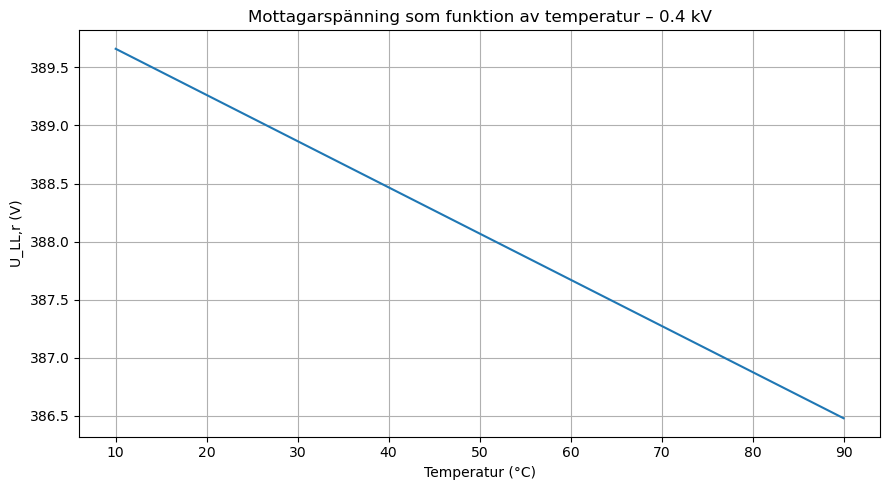

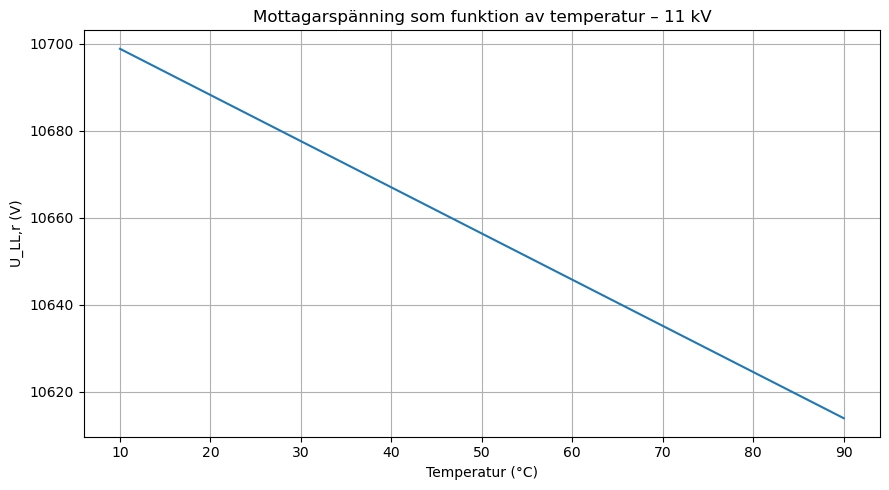

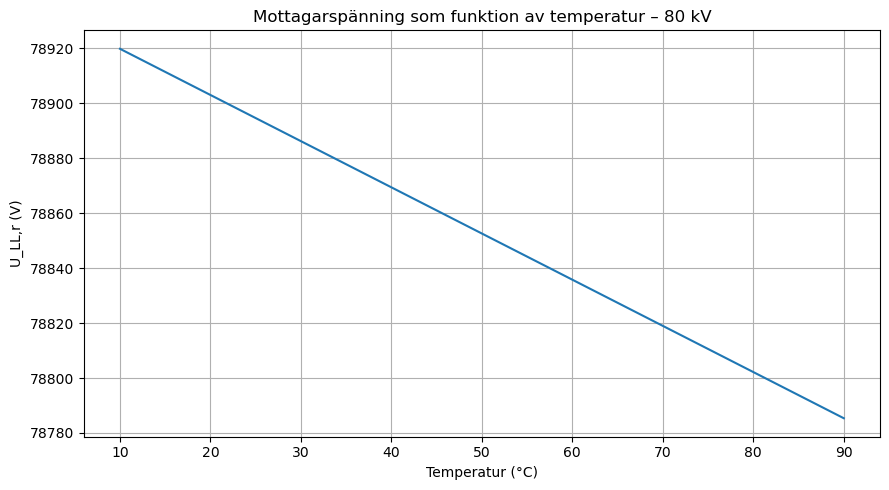

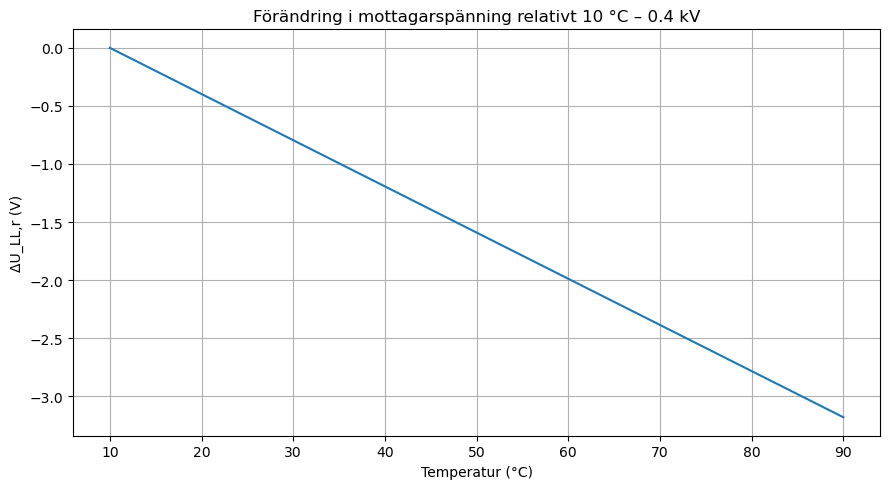

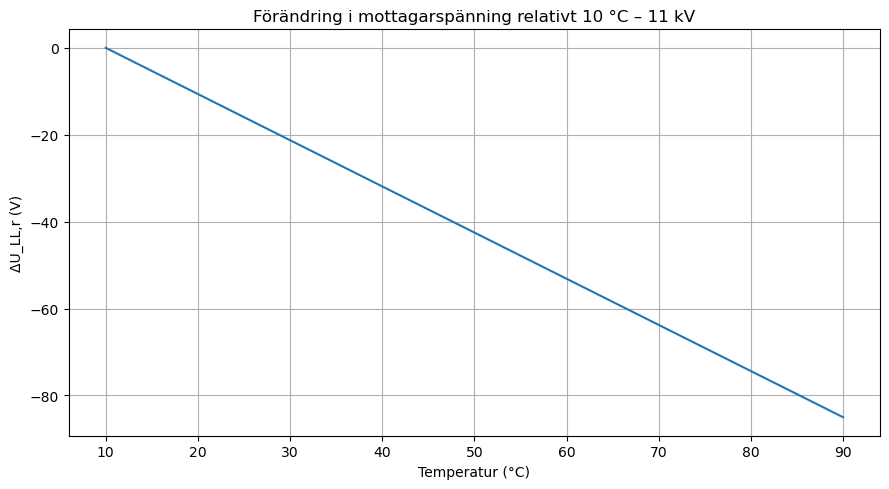

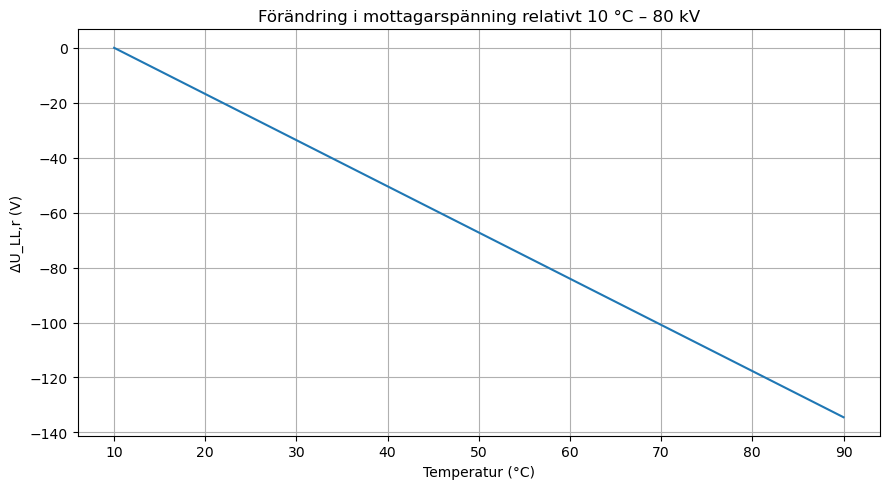

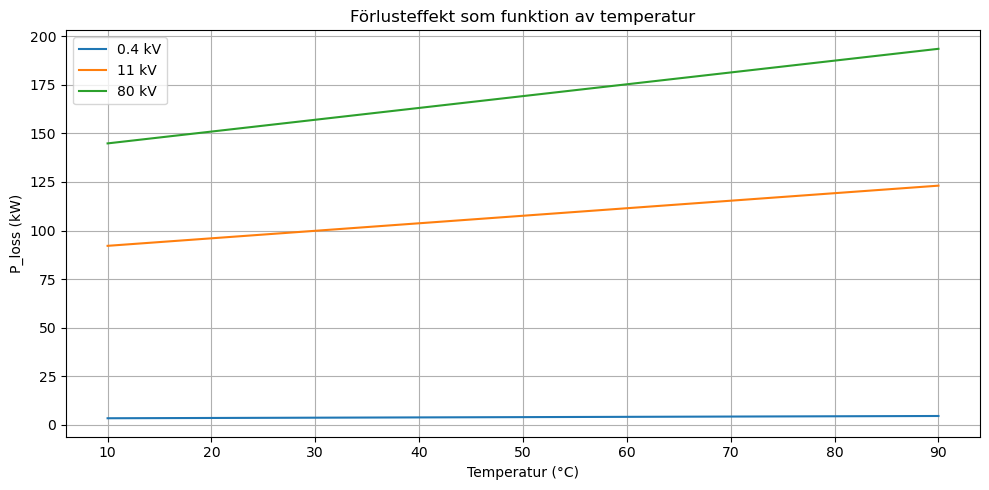

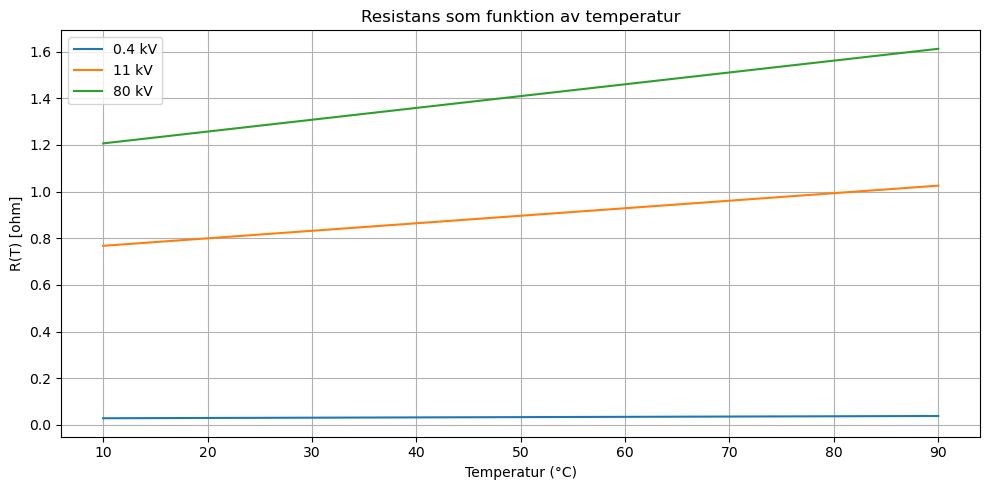

In [4]:
# ============================================================
# FRAMÅTRIKTAD LÄNKMODELL + EXTRA KOLUMNER + SPARA
# Hur mycket ändras andra sidan när temperaturen går 10 -> 90 °C?
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ============================================================
# PARAMETRAR
# ============================================================

alpha = 0.00403  # 1/K
T_min = 10
T_max = 90

# ============================================================
# FRAMÅTRIKTAD MODELL
# ============================================================

def run_case(label, U_LL_s, I_A, cosphi, R20_ohm, X_ohm, T_min=10, T_max=90):
    """
    Enkel seriemodell per fas:
        V_s = V_r + Z(T) I
        V_r = V_s - Z(T) I
        Z(T) = R(T) + jX
        R(T) = R20 * (1 + alpha * (T - 20))
    """

    # Effektfaktorvinkel
    phi_deg = np.degrees(np.arccos(cosphi))

    # Per-fas modell (balanserad trefas)
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)   # sändarspänning som referens
    Iph = polar(I_A, -phi_deg)             # induktiv last: ström efter spänning

    rows = []
    for T in range(T_min, T_max + 1):
        R = R20_ohm * (1 + alpha * (T - 20.0))
        Z = R + 1j * X_ohm

        Vr = Vs - Z * Iph
        Sr = 3 * Vr * np.conj(Iph)         # total trefaseffekt i mottagaränden
        Pr = np.real(Sr)
        Qr = np.imag(Sr)

        P_loss = 3 * (I_A ** 2) * R        # total trefas I²R-förlust

        rows.append({
            "Exempel": label,
            "T_C": T,
            "U_LL_s_V": U_LL_s,
            "I_A": I_A,
            "cosphi": cosphi,
            "phi_deg": phi_deg,
            "R20_Ohm": R20_ohm,
            "R_Ohm": R,
            "X_Ohm": X_ohm,
            "Vr_LL_V": abs(Vr) * np.sqrt(3),
            "Vr_ang_deg": np.degrees(np.angle(Vr)),
            "P_rec_W": Pr,
            "Q_rec_var": Qr,
            "P_loss_W": P_loss,
        })

    df = pd.DataFrame(rows)

    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    print(f"\n=== {label} ===")
    print(f"U_LL,s = {U_LL_s:.1f} V")
    print(f"I = {I_A:.1f} A")
    print(f"cos(phi) = {cosphi:.3f}")
    print(f"phi = {phi_deg:.3f} deg")
    print(f"R20 = {R20_ohm:.6f} ohm")
    print(f"X = {X_ohm:.6f} ohm")

    print("\nVid 10 °C:")
    print(f"  R(10)      = {row10['R_Ohm']:.6f} ohm")
    print(f"  Vr_LL(10)  = {row10['Vr_LL_V']:.2f} V")
    print(f"  Vr_ang(10) = {row10['Vr_ang_deg']:.6f} deg")
    print(f"  P_loss(10) = {row10['P_loss_W']:.2f} W")

    print("\nVid 90 °C:")
    print(f"  R(90)      = {row90['R_Ohm']:.6f} ohm")
    print(f"  Vr_LL(90)  = {row90['Vr_LL_V']:.2f} V")
    print(f"  Vr_ang(90) = {row90['Vr_ang_deg']:.6f} deg")
    print(f"  P_loss(90) = {row90['P_loss_W']:.2f} W")

    print("\nSkillnad 10 -> 90 °C:")
    print(f"  Delta R      = {row90['R_Ohm'] - row10['R_Ohm']:.6f} ohm")
    print(f"  Delta Vr_LL  = {row90['Vr_LL_V'] - row10['Vr_LL_V']:.2f} V")
    print(f"  Delta Vr_ang = {row90['Vr_ang_deg'] - row10['Vr_ang_deg']:.6f} deg")
    print(f"  Delta P_loss = {row90['P_loss_W'] - row10['P_loss_W']:.2f} W")

    return df

# ============================================================
# TRE EXEMPEL
# 0.4 kV och 11 kV är illustrativa
# 80 kV använder Bohus-lik nivå:
#   R20 = 0.0729 * 17.25 = 1.2575 ohm
#   X   = 0.38 * 17.25   = 6.555 ohm
# ============================================================

df_04 = run_case(
    label="0.4 kV",
    U_LL_s=400.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=0.030,
    X_ohm=0.008,
    T_min=T_min,
    T_max=T_max
)

df_11 = run_case(
    label="11 kV",
    U_LL_s=11000.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=0.800,
    X_ohm=0.450,
    T_min=T_min,
    T_max=T_max
)

df_80 = run_case(
    label="80 kV",
    U_LL_s=80000.0,
    I_A=200.0,
    cosphi=0.95,
    R20_ohm=1.2575,
    X_ohm=6.555,
    T_min=T_min,
    T_max=T_max
)

# ============================================================
# SAMMANFATTNINGSTABELL 10 °C / 90 °C
# ============================================================

def pick_summary(df, label):
    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]
    return {
        "Exempel": label,
        "R_10_Ohm": row10["R_Ohm"],
        "R_90_Ohm": row90["R_Ohm"],
        "Vr_10_V": row10["Vr_LL_V"],
        "Vr_90_V": row90["Vr_LL_V"],
        "Delta_Vr_V": row90["Vr_LL_V"] - row10["Vr_LL_V"],
        "Vr_ang_10_deg": row10["Vr_ang_deg"],
        "Vr_ang_90_deg": row90["Vr_ang_deg"],
        "Delta_Vr_ang_deg": row90["Vr_ang_deg"] - row10["Vr_ang_deg"],
        "P_loss_10_W": row10["P_loss_W"],
        "P_loss_90_W": row90["P_loss_W"],
        "Delta_P_loss_W": row90["P_loss_W"] - row10["P_loss_W"],
    }

summary = pd.DataFrame([
    pick_summary(df_04, "0.4 kV"),
    pick_summary(df_11, "11 kV"),
    pick_summary(df_80, "80 kV"),
])

# ============================================================
# EXTRA KOLUMNER
# ============================================================

delta_T_total = T_max - T_min
n_5C_steps = delta_T_total / 5.0   # 10 -> 90 => 16 steg om 5 °C

# relativ spänningsändring i %
summary["Delta_Vr_pct"] = 100.0 * summary["Delta_Vr_V"] / summary["Vr_10_V"]
summary["Delta_Vr_abs_pct"] = 100.0 * summary["Delta_Vr_V"].abs() / summary["Vr_10_V"]

# spänningsändring per 5 °C
summary["Delta_Vr_per_5C_V"] = summary["Delta_Vr_V"] / n_5C_steps
summary["Delta_Vr_abs_per_5C_V"] = summary["Delta_Vr_V"].abs() / n_5C_steps

# förluständring per 5 °C
summary["Delta_P_loss_per_5C_W"] = summary["Delta_P_loss_W"] / n_5C_steps
summary["Delta_P_loss_per_5C_kW"] = summary["Delta_P_loss_per_5C_W"] / 1000.0

# resistansändring per 5 °C
summary["Delta_R_per_5C_Ohm"] = (summary["R_90_Ohm"] - summary["R_10_Ohm"]) / n_5C_steps

summary_view = summary[[
    "Exempel",
    "R_10_Ohm", "R_90_Ohm", "Delta_R_per_5C_Ohm",
    "Vr_10_V", "Vr_90_V", "Delta_Vr_V", "Delta_Vr_pct", "Delta_Vr_abs_pct",
    "Delta_Vr_per_5C_V", "Delta_Vr_abs_per_5C_V",
    "P_loss_10_W", "P_loss_90_W", "Delta_P_loss_W", "Delta_P_loss_per_5C_W", "Delta_P_loss_per_5C_kW"
]].copy()

print("\n=== SAMMANFATTNING MED EXTRA KOLUMNER ===")
print(summary_view.round(4))

# ============================================================
# SPARA
# ============================================================

VERSION = "framatriktad_lankmodell_10_90C_med_extra_kolumner_01"

output_dir = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data") / safe_folder_name(VERSION)
output_dir.mkdir(parents=True, exist_ok=True)

summary.to_excel(output_dir / "summary_full.xlsx", index=False)
summary_view.to_excel(output_dir / "summary_with_extra_columns.xlsx", index=False)
summary.to_csv(output_dir / "summary_full.csv", index=False)
summary_view.to_csv(output_dir / "summary_with_extra_columns.csv", index=False)

df_04.to_excel(output_dir / "case_0_4kV.xlsx", index=False)
df_11.to_excel(output_dir / "case_11kV.xlsx", index=False)
df_80.to_excel(output_dir / "case_80kV.xlsx", index=False)

print("\nSparat till:", output_dir.resolve())

# ============================================================
# PLOT 1: Mottagarspänning vs temperatur
# SEPARATA GRAFER
# ============================================================

cases = [
    ("0.4 kV", df_04, "0_4kV"),
    ("11 kV", df_11, "11kV"),
    ("80 kV", df_80, "80kV"),
]

for label, df_case, tag in cases:
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], df_case["Vr_LL_V"])
    plt.title(f"Mottagarspänning som funktion av temperatur – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Vr_vs_T_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# PLOT 1B: Förändring i mottagarspänning relativt 10 °C
# SEPARATA GRAFER
# ============================================================

for label, df_case, tag in cases:
    Vr0 = df_case.loc[df_case["T_C"] == 10, "Vr_LL_V"].iloc[0]
    delta_V = df_case["Vr_LL_V"] - Vr0

    plt.figure(figsize=(9, 5))
    plt.plot(df_case["T_C"], delta_V)
    plt.title(f"Förändring i mottagarspänning relativt 10 °C – {label}")
    plt.xlabel("Temperatur (°C)")
    plt.ylabel("ΔU_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_vs_T_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# PLOT 2: Förlusteffekt vs temperatur
# GEMENSAM FIGUR
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["P_loss_W"]/1000, label="0.4 kV")
plt.plot(df_11["T_C"], df_11["P_loss_W"]/1000, label="11 kV")
plt.plot(df_80["T_C"], df_80["P_loss_W"]/1000, label="80 kV")
plt.title("Förlusteffekt som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("P_loss (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "Ploss_vs_T_all.png", dpi=200)
plt.show()

# ============================================================
# PLOT 3: Resistans vs temperatur
# GEMENSAM FIGUR
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(df_04["T_C"], df_04["R_Ohm"], label="0.4 kV")
plt.plot(df_11["T_C"], df_11["R_Ohm"], label="11 kV")
plt.plot(df_80["T_C"], df_80["R_Ohm"], label="80 kV")
plt.title("Resistans som funktion av temperatur")
plt.xlabel("Temperatur (°C)")
plt.ylabel("R(T) [ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "R_vs_T_all.png", dpi=200)
plt.show()